In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.utils import resample
from google.colab import drive
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score, roc_curve, auc
drive.mount('/content/drive')

data = pd.read_csv('/content/drive/MyDrive/MU projekat/Modeli/Decision Tree/dataset22.csv')

print(data.info())
print(data.describe())


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 98438 entries, 0 to 98437
Data columns (total 31 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Month                     98438 non-null  object 
 1   Occupation                91511 non-null  object 
 2   Annual_Income             98438 non-null  float64
 3   Num_Bank_Accounts         98438 non-null  int64  
 4   Num_Credit_Card           98438 non-null  float64
 5   Interest_Rate             98438 non-null  float64
 6   Num_of_Loan               98438 non-null  float64
 7   Delay_from_due_date       98438 non-null  int64  
 8   Num_of_Delayed_Payment    98438 non-null  float64
 9   Changed_Credit_Limit      98438 non-null  float64
 10  Num_Credit_Inquiries      98438 non-null  float64
 11  Credit_Mix                98438 non-null  

In [ ]:
print("Nedostajuće vrijednosti po kolonama:\n", data.isnull().sum())


Nedostajuće vrijednosti po kolonama:
 Month                          0
Occupation                  6927
Annual_Income                  0
Num_Bank_Accounts              0
Num_Credit_Card                0
Interest_Rate                  0
Num_of_Loan                    0
Delay_from_due_date            0
Num_of_Delayed_Payment         0
Changed_Credit_Limit           0
Num_Credit_Inquiries           0
Credit_Mix                     0
Outstanding_Debt               0
Credit_Utilization_Ratio       0
Credit_History_Age             0
Payment_of_Min_Amount          0
Total_EMI_per_month            0
Amount_invested_monthly     4409
Payment_Behaviour              0
Monthly_Balance                0
Credit_Score                   0
Age                            0
Auto Loan                      0
Credit-Builder Loan            0
Personal Loan                  0
Home Equity Loan               0
Not Specified                  0
Mortgage Loan                  0
Student Loan                   0
Debt 

In [ ]:
label_encoder = LabelEncoder()
for col in data.select_dtypes(include=['object']).columns:
    data[col] = label_encoder.fit_transform(data[col])

In [ ]:
target_col = 'Credit_Score'
print("Distribucija ciljne varijable:\n", data[target_col].value_counts())

Distribucija ciljne varijable:
 Credit_Score
2    52363
1    28518
0    17557
Name: count, dtype: int64


In [ ]:
data['Occupation'] = data['Occupation'].fillna(data['Occupation'].mode()[0])
data['Amount_invested_monthly'] = data['Amount_invested_monthly'].fillna(data['Amount_invested_monthly'].median())


In [ ]:
X = data.drop('Credit_Score', axis=1)
y = data['Credit_Score']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


Rezultati za NEBALANSIRANI dataset:
Konfuzijska matrica:
 [[2019  204 1288]
 [ 230 3765 1709]
 [1186 1724 7563]]

Izvještaj klasifikacije:
               precision    recall  f1-score   support

           0       0.59      0.58      0.58      3511
           1       0.66      0.66      0.66      5704
           2       0.72      0.72      0.72     10473

    accuracy                           0.68     19688
   macro avg       0.66      0.65      0.65     19688
weighted avg       0.68      0.68      0.68     19688

Tačnost: 0.6779256399837464


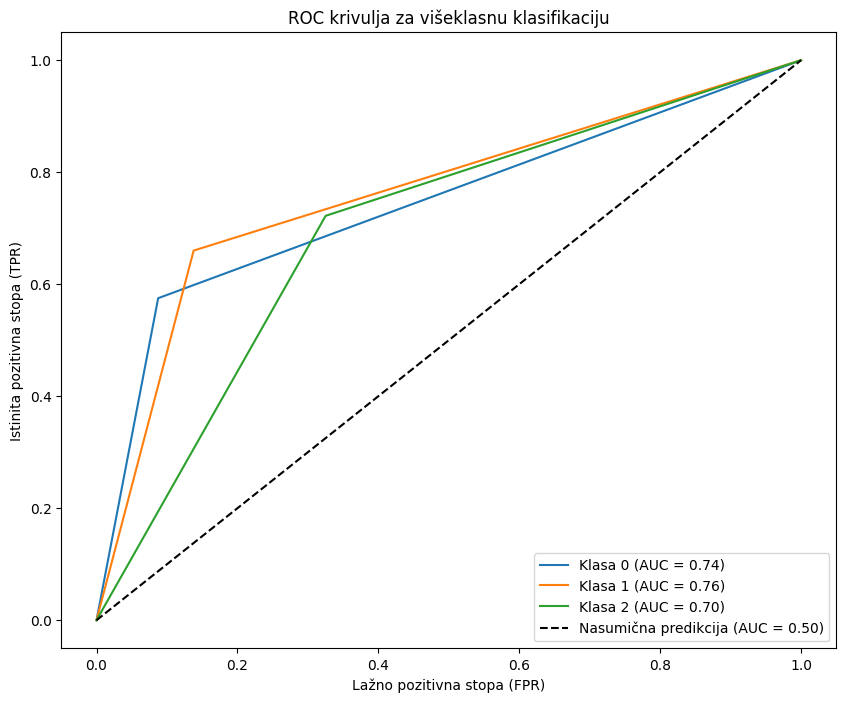

Macro-average AUC: 0.73
Weighted-average AUC: 0.72


In [ ]:
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt


dt_model = DecisionTreeClassifier(
    criterion='gini',
    random_state=42
)
dt_model.fit(X_train, y_train)

y_pred = dt_model.predict(X_test)

print("Rezultati za NEBALANSIRANI dataset:")
print("Konfuzijska matrica:\n", confusion_matrix(y_test, y_pred))
print("\nIzvještaj klasifikacije:\n", classification_report(y_test, y_pred))
print("Tačnost:", accuracy_score(y_test, y_pred))

n_classes = len(set(y_test))
y_test_binarized = label_binarize(y_test, classes=[0, 1, 2])
y_pred_proba = dt_model.predict_proba(X_test)


fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_binarized[:, i], y_pred_proba[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(10, 8))
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], label=f"Klasa {i} (AUC = {roc_auc[i]:.2f})")

plt.plot([0, 1], [0, 1], "k--", label="Nasumična predikcija (AUC = 0.50)")

plt.title("ROC krivulja za višeklasnu klasifikaciju")
plt.xlabel("Lažno pozitivna stopa (FPR)")
plt.ylabel("Istinita pozitivna stopa (TPR)")
plt.legend(loc="lower right")
plt.show()

macro_roc_auc = roc_auc_score(y_test_binarized, y_pred_proba, average='macro')
weighted_roc_auc = roc_auc_score(y_test_binarized, y_pred_proba, average='weighted')

print(f"Macro-average AUC: {macro_roc_auc:.2f}")
print(f"Weighted-average AUC: {weighted_roc_auc:.2f}")

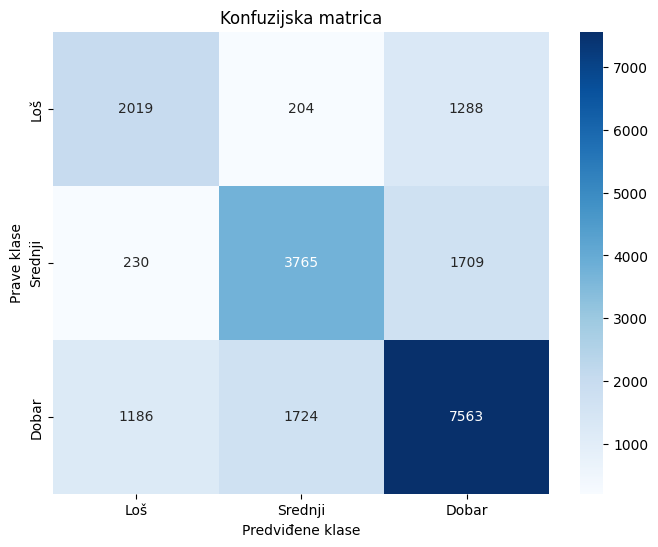

In [ ]:
import seaborn as sns
import numpy as np


conf_matrix = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap="Blues",
            xticklabels=["Loš", "Srednji", "Dobar"],
            yticklabels=["Loš", "Srednji", "Dobar"])
plt.title("Konfuzijska matrica")
plt.xlabel("Predviđene klase")
plt.ylabel("Prave klase")
plt.show()


In [ ]:
from sklearn.utils import resample

data_combined = pd.concat([X, y], axis=1)


class_0 = data_combined[data_combined['Credit_Score'] == 0]
class_1 = data_combined[data_combined['Credit_Score'] == 1]
class_2 = data_combined[data_combined['Credit_Score'] == 2]


class_0_upsampled = resample(class_0, replace=True, n_samples=len(class_2), random_state=42)
class_1_upsampled = resample(class_1, replace=True, n_samples=len(class_2), random_state=42)


data_balanced = pd.concat([class_0_upsampled, class_1_upsampled, class_2])


X_balanced = data_balanced.drop('Credit_Score', axis=1)
y_balanced = data_balanced['Credit_Score']

print("Distribucija ciljne varijable nakon balansiranja:\n", y_balanced.value_counts())


Distribucija ciljne varijable nakon balansiranja:
 Credit_Score
0    52363
1    52363
2    52363
Name: count, dtype: int64



Rezultati za BALANSIRANI dataset:
Konfuzijska matrica:
 [[10111    56   305]
 [   76  9670   727]
 [ 1263  1731  7479]]

Izvještaj klasifikacije:
               precision    recall  f1-score   support

           0       0.88      0.97      0.92     10472
           1       0.84      0.92      0.88     10473
           2       0.88      0.71      0.79     10473

    accuracy                           0.87     31418
   macro avg       0.87      0.87      0.86     31418
weighted avg       0.87      0.87      0.86     31418

Tačnost: 0.8676554841173849


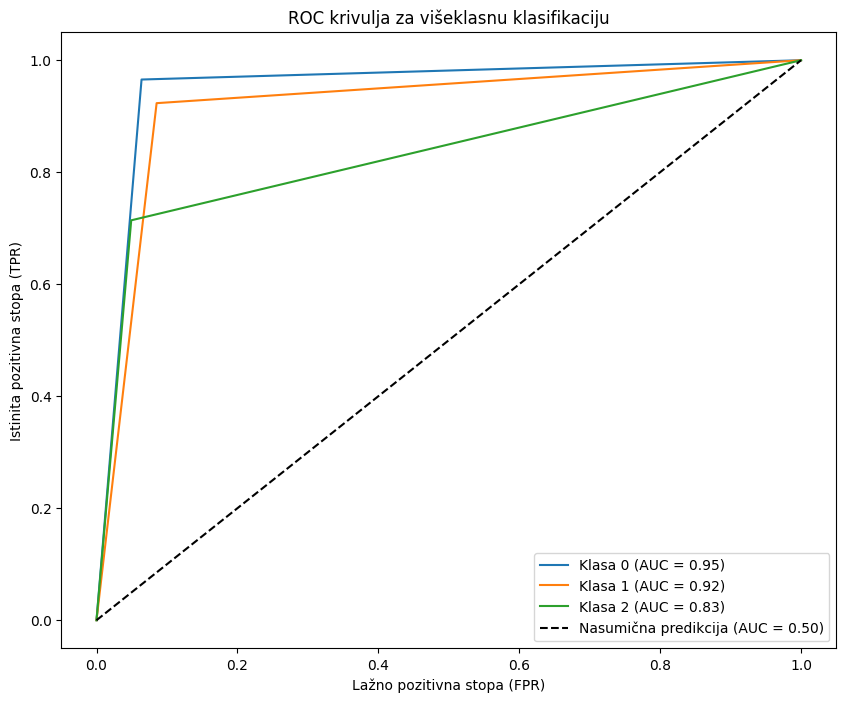

Macro-average AUC: 0.90
Weighted-average AUC: 0.90


In [ ]:

X_train_bal, X_test_bal, y_train_bal, y_test_bal = train_test_split(X_balanced, y_balanced, test_size=0.2, random_state=42, stratify=y_balanced)


dt_model_bal = DecisionTreeClassifier(
    criterion='gini',
    random_state=42
)
dt_model_bal.fit(X_train_bal, y_train_bal)


y_pred_bal = dt_model_bal.predict(X_test_bal)


print("\nRezultati za BALANSIRANI dataset:")
print("Konfuzijska matrica:\n", confusion_matrix(y_test_bal, y_pred_bal))
print("\nIzvještaj klasifikacije:\n", classification_report(y_test_bal, y_pred_bal))
print("Tačnost:", accuracy_score(y_test_bal, y_pred_bal))


n_classes = len(set(y_test_bal))
y_test_binarized = label_binarize(y_test_bal, classes=[0, 1, 2])
y_pred_proba = dt_model_bal.predict_proba(X_test_bal)


fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_binarized[:, i], y_pred_proba[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])


plt.figure(figsize=(10, 8))
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], label=f"Klasa {i} (AUC = {roc_auc[i]:.2f})")


plt.plot([0, 1], [0, 1], "k--", label="Nasumična predikcija (AUC = 0.50)")

plt.title("ROC krivulja za višeklasnu klasifikaciju")
plt.xlabel("Lažno pozitivna stopa (FPR)")
plt.ylabel("Istinita pozitivna stopa (TPR)")
plt.legend(loc="lower right")
plt.show()

macro_roc_auc = roc_auc_score(y_test_binarized, y_pred_proba, average='macro')
weighted_roc_auc = roc_auc_score(y_test_binarized, y_pred_proba, average='weighted')

print(f"Macro-average AUC: {macro_roc_auc:.2f}")
print(f"Weighted-average AUC: {weighted_roc_auc:.2f}")

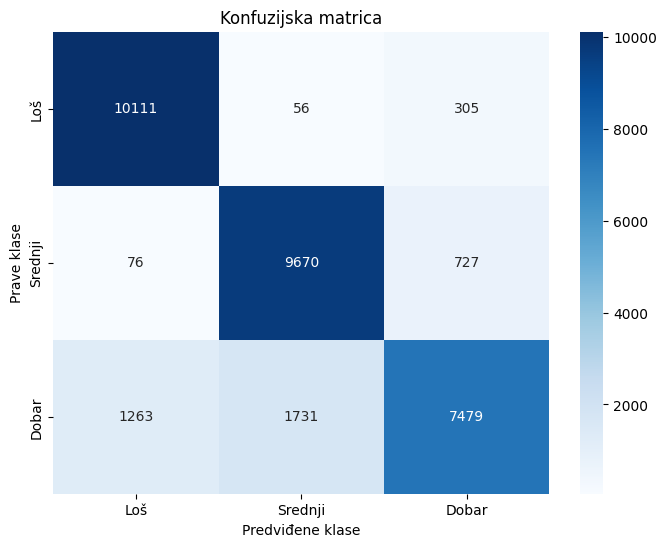

In [ ]:
import seaborn as sns
import numpy as np


conf_matrix = confusion_matrix(y_test_bal, y_pred_bal)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap="Blues",
            xticklabels=["Loš", "Srednji", "Dobar"],
            yticklabels=["Loš", "Srednji", "Dobar"])
plt.title("Konfuzijska matrica")
plt.xlabel("Predviđene klase")
plt.ylabel("Prave klase")
plt.show()


Rezultati modela s ograničenjem dubine (max_depth=10):
Konfuzijska matrica:
 [[2235  102 1174]
 [ 368 3880 1456]
 [1248 1412 7813]]

Izvještaj klasifikacije:
               precision    recall  f1-score   support

           0       0.58      0.64      0.61      3511
           1       0.72      0.68      0.70      5704
           2       0.75      0.75      0.75     10473

    accuracy                           0.71     19688
   macro avg       0.68      0.69      0.68     19688
weighted avg       0.71      0.71      0.71     19688

Tačnost: 0.7074360016253556


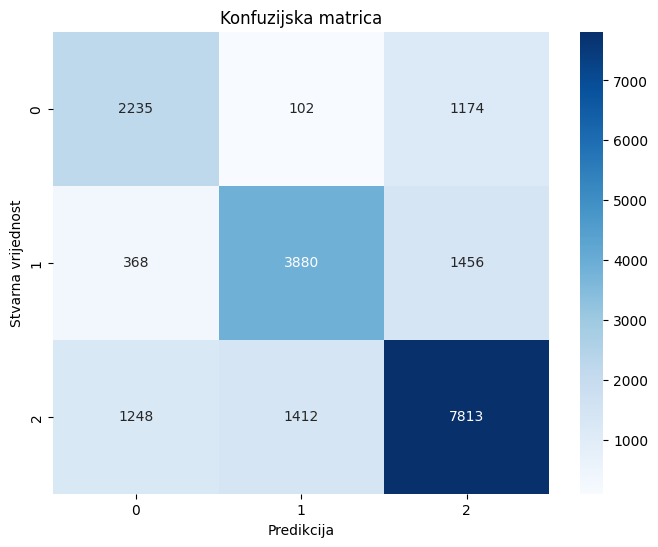

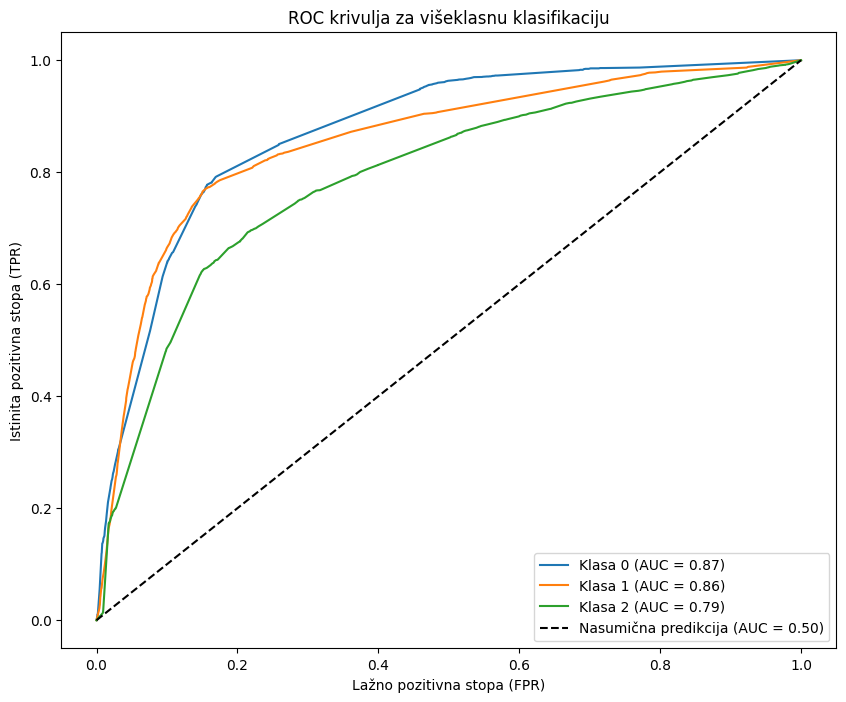

Macro-average AUC: 0.84
Weighted-average AUC: 0.82


In [ ]:
dt_model_depth = DecisionTreeClassifier(max_depth=10, random_state=42)
dt_model_depth.fit(X_train, y_train)
y_pred_depth = dt_model_depth.predict(X_test)

print("Rezultati modela s ograničenjem dubine (max_depth=10):")
print("Konfuzijska matrica:\n", confusion_matrix(y_test, y_pred_depth))
print("\nIzvještaj klasifikacije:\n", classification_report(y_test, y_pred_depth))
print("Tačnost:", accuracy_score(y_test, y_pred_depth))

conf_matrix = confusion_matrix(y_test, y_pred_depth)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=['0', '1', '2'], yticklabels=['0', '1', '2'])
plt.title('Konfuzijska matrica')
plt.xlabel('Predikcija')
plt.ylabel('Stvarna vrijednost')
plt.show()

n_classes = len(set(y_test))
y_test_binarized = label_binarize(y_test, classes=[0, 1, 2])
y_pred_proba = dt_model_depth.predict_proba(X_test)

fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_binarized[:, i], y_pred_proba[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])


plt.figure(figsize=(10, 8))
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], label=f"Klasa {i} (AUC = {roc_auc[i]:.2f})")

plt.plot([0, 1], [0, 1], "k--", label="Nasumična predikcija (AUC = 0.50)")
plt.title("ROC krivulja za višeklasnu klasifikaciju")
plt.xlabel("Lažno pozitivna stopa (FPR)")
plt.ylabel("Istinita pozitivna stopa (TPR)")
plt.legend(loc="lower right")
plt.show()

macro_roc_auc = roc_auc_score(y_test_binarized, y_pred_proba, average='macro')
weighted_roc_auc = roc_auc_score(y_test_binarized, y_pred_proba, average='weighted')

print(f"Macro-average AUC: {macro_roc_auc:.2f}")
print(f"Weighted-average AUC: {weighted_roc_auc:.2f}")

Rezultati modela s ograničenjem dubine (max_depth=10):
Konfuzijska matrica:
 [[8360  278 1834]
 [1010 8032 1431]
 [1900 1974 6599]]

Izvještaj klasifikacije:
               precision    recall  f1-score   support

           0       0.74      0.80      0.77     10472
           1       0.78      0.77      0.77     10473
           2       0.67      0.63      0.65     10473

    accuracy                           0.73     31418
   macro avg       0.73      0.73      0.73     31418
weighted avg       0.73      0.73      0.73     31418

Tačnost: 0.731777961678019


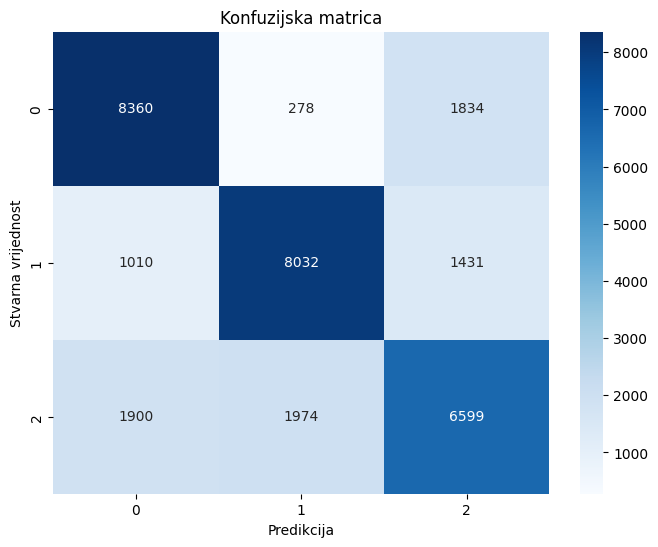

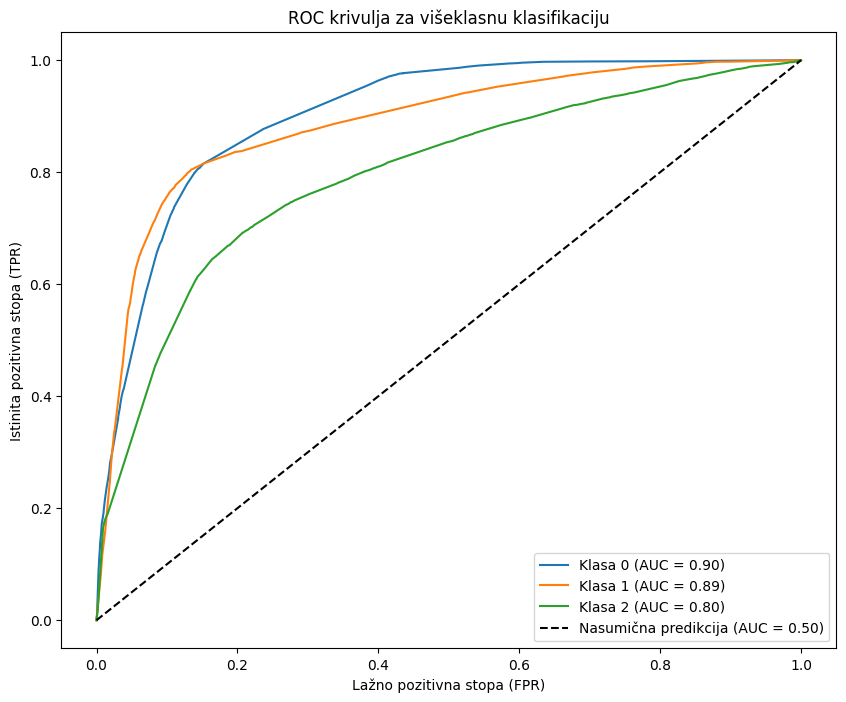

Macro-average AUC: 0.86
Weighted-average AUC: 0.86


In [ ]:
dt_model_depth = DecisionTreeClassifier(max_depth=10, random_state=42)
dt_model_depth.fit(X_train_bal, y_train_bal)
y_pred_depth = dt_model_depth.predict(X_test_bal)

print("Rezultati modela s ograničenjem dubine (max_depth=10):")
print("Konfuzijska matrica:\n", confusion_matrix(y_test_bal, y_pred_depth))
print("\nIzvještaj klasifikacije:\n", classification_report(y_test_bal, y_pred_depth))
print("Tačnost:", accuracy_score(y_test_bal, y_pred_depth))

conf_matrix = confusion_matrix(y_test_bal, y_pred_depth)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=['0', '1', '2'], yticklabels=['0', '1', '2'])
plt.title('Konfuzijska matrica')
plt.xlabel('Predikcija')
plt.ylabel('Stvarna vrijednost')
plt.show()


n_classes = len(set(y_test_bal))
y_test_binarized = label_binarize(y_test_bal, classes=[0, 1, 2])
y_pred_proba = dt_model_depth.predict_proba(X_test_bal)

fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_binarized[:, i], y_pred_proba[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])


plt.figure(figsize=(10, 8))
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], label=f"Klasa {i} (AUC = {roc_auc[i]:.2f})")

plt.plot([0, 1], [0, 1], "k--", label="Nasumična predikcija (AUC = 0.50)")
plt.title("ROC krivulja za višeklasnu klasifikaciju")
plt.xlabel("Lažno pozitivna stopa (FPR)")
plt.ylabel("Istinita pozitivna stopa (TPR)")
plt.legend(loc="lower right")
plt.show()
macro_roc_auc = roc_auc_score(y_test_binarized, y_pred_proba, average='macro')
weighted_roc_auc = roc_auc_score(y_test_binarized, y_pred_proba, average='weighted')

print(f"Macro-average AUC: {macro_roc_auc:.2f}")
print(f"Weighted-average AUC: {weighted_roc_auc:.2f}")

Rezultati modela
Konfuzijska matrica:
 [[2044  236 1231]
 [ 247 3841 1616]
 [1250 1628 7595]]

Izvještaj klasifikacije:
               precision    recall  f1-score   support

           0       0.58      0.58      0.58      3511
           1       0.67      0.67      0.67      5704
           2       0.73      0.73      0.73     10473

    accuracy                           0.68     19688
   macro avg       0.66      0.66      0.66     19688
weighted avg       0.68      0.68      0.68     19688

Tačnost: 0.6846810239739943


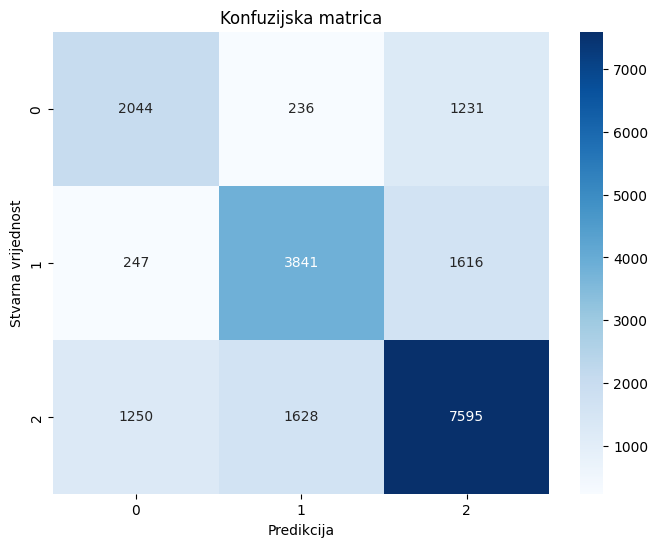

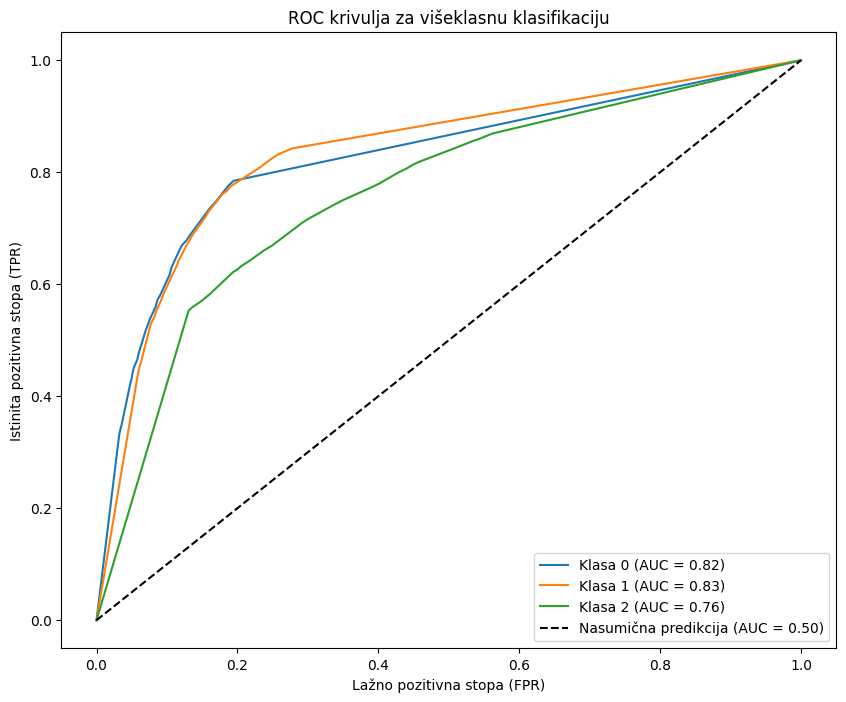

Macro-average AUC: 0.81
Weighted-average AUC: 0.79


In [ ]:
dt_model_min_samples = DecisionTreeClassifier(min_samples_split=10, min_samples_leaf=5, random_state=42)
dt_model_min_samples.fit(X_train, y_train)
y_pred_min_samples = dt_model_min_samples.predict(X_test)

print("Rezultati modela")
print("Konfuzijska matrica:\n", confusion_matrix(y_test, y_pred_min_samples))
print("\nIzvještaj klasifikacije:\n", classification_report(y_test, y_pred_min_samples))
print("Tačnost:", accuracy_score(y_test, y_pred_min_samples))

conf_matrix = confusion_matrix(y_test, y_pred_min_samples)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=['0', '1', '2'], yticklabels=['0', '1', '2'])
plt.title('Konfuzijska matrica')
plt.xlabel('Predikcija')
plt.ylabel('Stvarna vrijednost')
plt.show()

n_classes = len(set(y_test))
y_test_binarized = label_binarize(y_test, classes=[0, 1, 2])

y_pred_proba = dt_model_min_samples.predict_proba(X_test)

fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_binarized[:, i], y_pred_proba[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(10, 8))
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], label=f"Klasa {i} (AUC = {roc_auc[i]:.2f})")

plt.plot([0, 1], [0, 1], "k--", label="Nasumična predikcija (AUC = 0.50)")
plt.title("ROC krivulja za višeklasnu klasifikaciju")
plt.xlabel("Lažno pozitivna stopa (FPR)")
plt.ylabel("Istinita pozitivna stopa (TPR)")
plt.legend(loc="lower right")
plt.show()
macro_roc_auc = roc_auc_score(y_test_binarized, y_pred_proba, average='macro')
weighted_roc_auc = roc_auc_score(y_test_binarized, y_pred_proba, average='weighted')

print(f"Macro-average AUC: {macro_roc_auc:.2f}")
print(f"Weighted-average AUC: {weighted_roc_auc:.2f}")

Rezultati modela
Konfuzijska matrica:
 [[9430  194  848]
 [ 298 8934 1241]
 [1568 1906 6999]]

Izvještaj klasifikacije:
               precision    recall  f1-score   support

           0       0.83      0.90      0.87     10472
           1       0.81      0.85      0.83     10473
           2       0.77      0.67      0.72     10473

    accuracy                           0.81     31418
   macro avg       0.80      0.81      0.80     31418
weighted avg       0.80      0.81      0.80     31418

Tačnost: 0.8072760837736329


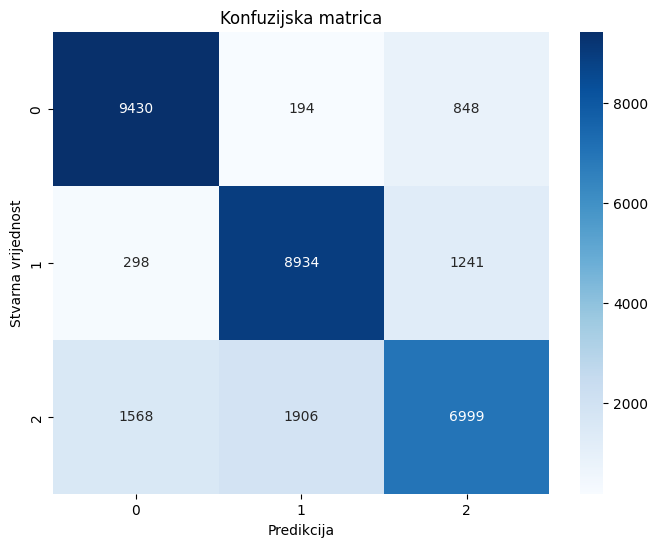

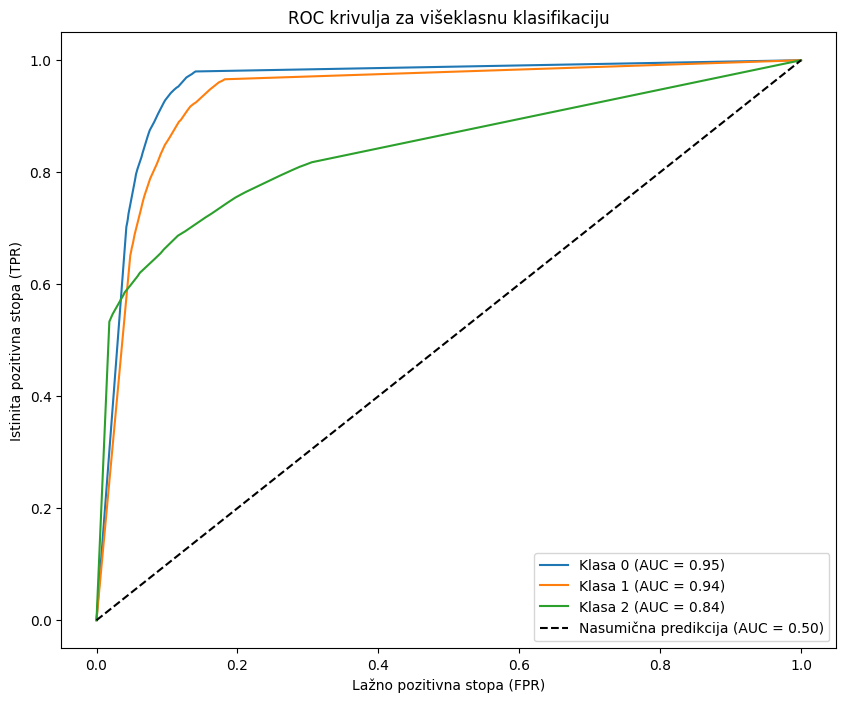

Macro-average AUC: 0.91
Weighted-average AUC: 0.91


In [ ]:
dt_model_min_samples = DecisionTreeClassifier(min_samples_split=10, min_samples_leaf=5, random_state=42)
dt_model_min_samples.fit(X_train_bal, y_train_bal)
y_pred_min_samples = dt_model_min_samples.predict(X_test_bal)

print("Rezultati modela")
print("Konfuzijska matrica:\n", confusion_matrix(y_test_bal, y_pred_min_samples))
print("\nIzvještaj klasifikacije:\n", classification_report(y_test_bal, y_pred_min_samples))
print("Tačnost:", accuracy_score(y_test_bal, y_pred_min_samples))

conf_matrix = confusion_matrix(y_test_bal, y_pred_min_samples)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=['0', '1', '2'], yticklabels=['0', '1', '2'])
plt.title('Konfuzijska matrica')
plt.xlabel('Predikcija')
plt.ylabel('Stvarna vrijednost')
plt.show()

n_classes = len(set(y_test_bal))
y_test_binarized = label_binarize(y_test_bal, classes=[0, 1, 2])

y_pred_proba = dt_model_min_samples.predict_proba(X_test_bal)

fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_binarized[:, i], y_pred_proba[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(10, 8))
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], label=f"Klasa {i} (AUC = {roc_auc[i]:.2f})")

plt.plot([0, 1], [0, 1], "k--", label="Nasumična predikcija (AUC = 0.50)")
plt.title("ROC krivulja za višeklasnu klasifikaciju")
plt.xlabel("Lažno pozitivna stopa (FPR)")
plt.ylabel("Istinita pozitivna stopa (TPR)")
plt.legend(loc="lower right")
plt.show()
macro_roc_auc = roc_auc_score(y_test_binarized, y_pred_proba, average='macro')
weighted_roc_auc = roc_auc_score(y_test_binarized, y_pred_proba, average='weighted')

print(f"Macro-average AUC: {macro_roc_auc:.2f}")
print(f"Weighted-average AUC: {weighted_roc_auc:.2f}")

Rezultati
Konfuzijska matrica:
 [[1865  294 1352]
 [ 306 3619 1779]
 [1354 1793 7326]]

Izvještaj klasifikacije:
               precision    recall  f1-score   support

           0       0.53      0.53      0.53      3511
           1       0.63      0.63      0.63      5704
           2       0.70      0.70      0.70     10473

    accuracy                           0.65     19688
   macro avg       0.62      0.62      0.62     19688
weighted avg       0.65      0.65      0.65     19688

Tačnost: 0.6506501422186103


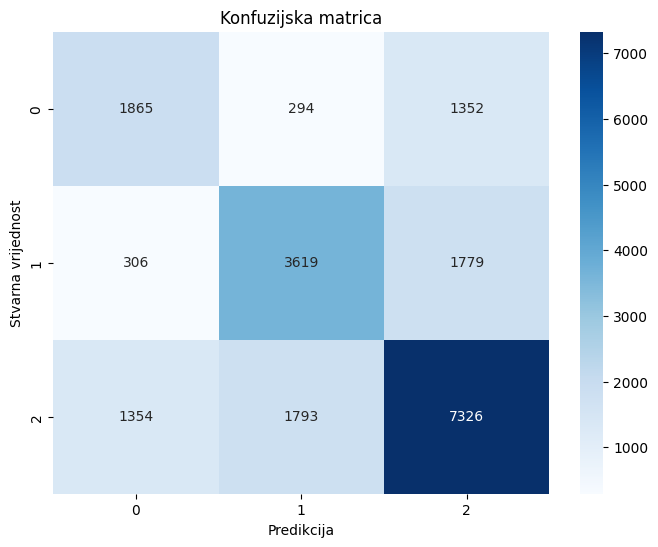

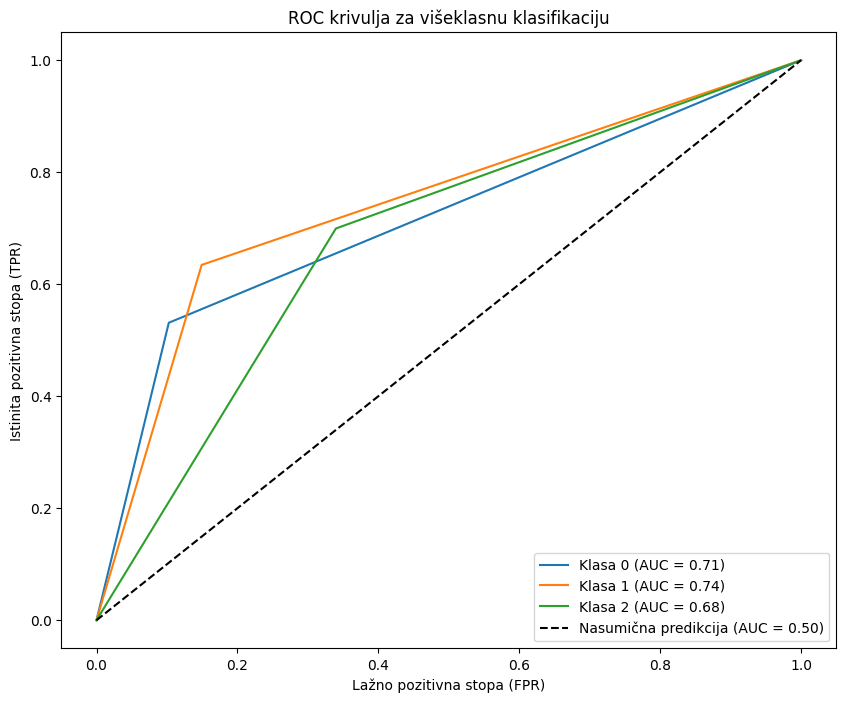

Macro-average AUC: 0.71
Weighted-average AUC: 0.70


In [ ]:
dt_model_max_features = DecisionTreeClassifier(max_features='sqrt', random_state=42)
dt_model_max_features.fit(X_train, y_train)
y_pred_max_features = dt_model_max_features.predict(X_test)

print("Rezultati")
print("Konfuzijska matrica:\n", confusion_matrix(y_test, y_pred_max_features))
print("\nIzvještaj klasifikacije:\n", classification_report(y_test, y_pred_max_features))
print("Tačnost:", accuracy_score(y_test, y_pred_max_features))

conf_matrix = confusion_matrix(y_test, y_pred_max_features)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=['0', '1', '2'], yticklabels=['0', '1', '2'])
plt.title('Konfuzijska matrica')
plt.xlabel('Predikcija')
plt.ylabel('Stvarna vrijednost')
plt.show()

n_classes = len(set(y_test))
y_test_binarized = label_binarize(y_test, classes=[0, 1, 2])

y_pred_proba = dt_model_max_features.predict_proba(X_test)
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_binarized[:, i], y_pred_proba[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])


plt.figure(figsize=(10, 8))
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], label=f"Klasa {i} (AUC = {roc_auc[i]:.2f})")

plt.plot([0, 1], [0, 1], "k--", label="Nasumična predikcija (AUC = 0.50)")
plt.title("ROC krivulja za višeklasnu klasifikaciju")
plt.xlabel("Lažno pozitivna stopa (FPR)")
plt.ylabel("Istinita pozitivna stopa (TPR)")
plt.legend(loc="lower right")
plt.show()
macro_roc_auc = roc_auc_score(y_test_binarized, y_pred_proba, average='macro')
weighted_roc_auc = roc_auc_score(y_test_binarized, y_pred_proba, average='weighted')

print(f"Macro-average AUC: {macro_roc_auc:.2f}")
print(f"Weighted-average AUC: {weighted_roc_auc:.2f}")

Rezultati modela
Konfuzijska matrica:
 [[10064    72   336]
 [  137  9559   777]
 [ 1394  1789  7290]]

Izvještaj klasifikacije:
               precision    recall  f1-score   support

           0       0.87      0.96      0.91     10472
           1       0.84      0.91      0.87     10473
           2       0.87      0.70      0.77     10473

    accuracy                           0.86     31418
   macro avg       0.86      0.86      0.85     31418
weighted avg       0.86      0.86      0.85     31418

Tačnost: 0.8566108600165511


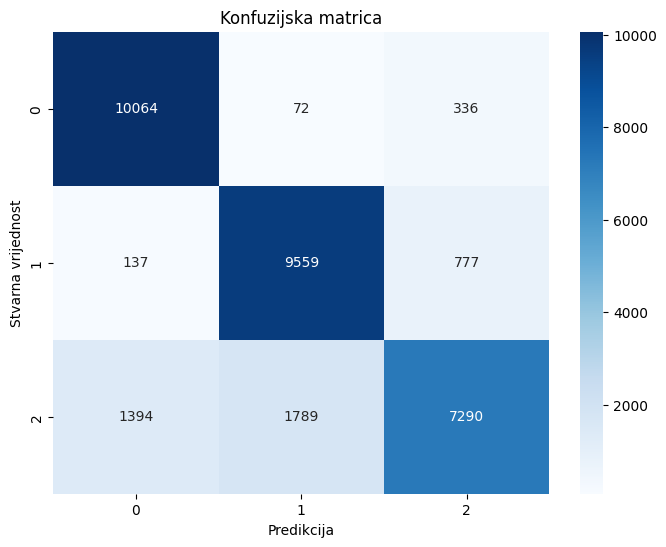

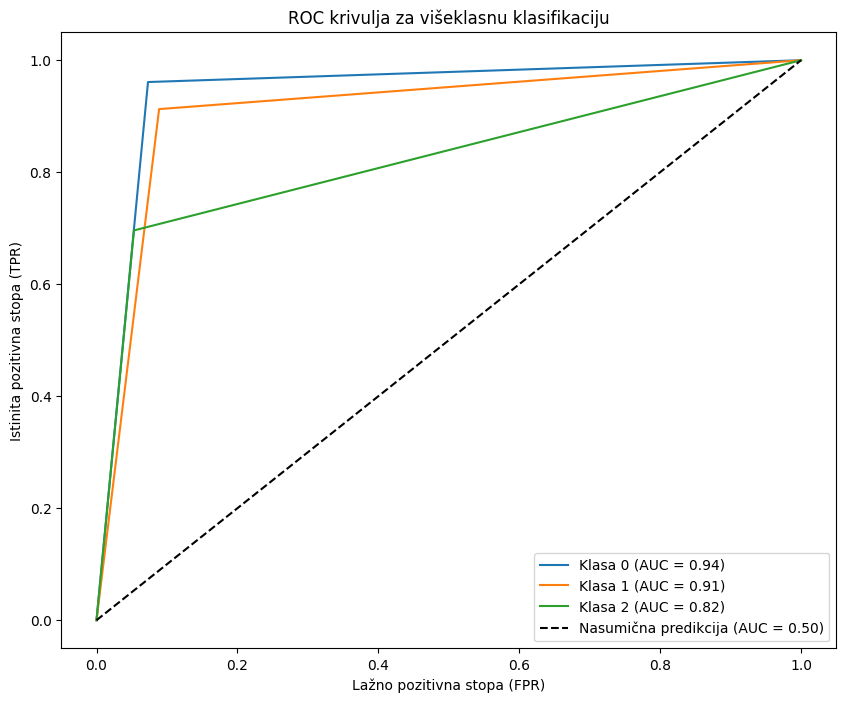

Macro-average AUC: 0.89
Weighted-average AUC: 0.89


In [ ]:
dt_model_max_features = DecisionTreeClassifier(max_features='sqrt', random_state=42)
dt_model_max_features.fit(X_train_bal, y_train_bal)
y_pred_max_features = dt_model_max_features.predict(X_test_bal)

print("Rezultati modela")
print("Konfuzijska matrica:\n", confusion_matrix(y_test_bal, y_pred_max_features))
print("\nIzvještaj klasifikacije:\n", classification_report(y_test_bal, y_pred_max_features))
print("Tačnost:", accuracy_score(y_test_bal, y_pred_max_features))

conf_matrix = confusion_matrix(y_test_bal, y_pred_max_features)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=['0', '1', '2'], yticklabels=['0', '1', '2'])
plt.title('Konfuzijska matrica')
plt.xlabel('Predikcija')
plt.ylabel('Stvarna vrijednost')
plt.show()

n_classes = len(set(y_test_bal))
y_test_binarized = label_binarize(y_test_bal, classes=[0, 1, 2])

y_pred_proba = dt_model_max_features.predict_proba(X_test_bal)

fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_binarized[:, i], y_pred_proba[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(10, 8))
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], label=f"Klasa {i} (AUC = {roc_auc[i]:.2f})")

plt.plot([0, 1], [0, 1], "k--", label="Nasumična predikcija (AUC = 0.50)")
plt.title("ROC krivulja za višeklasnu klasifikaciju")
plt.xlabel("Lažno pozitivna stopa (FPR)")
plt.ylabel("Istinita pozitivna stopa (TPR)")
plt.legend(loc="lower right")
plt.show()

macro_roc_auc = roc_auc_score(y_test_binarized, y_pred_proba, average='macro')
weighted_roc_auc = roc_auc_score(y_test_binarized, y_pred_proba, average='weighted')

print(f"Macro-average AUC: {macro_roc_auc:.2f}")
print(f"Weighted-average AUC: {weighted_roc_auc:.2f}")

Rezultati modela
Konfuzijska matrica:
 [[2062  203 1246]
 [ 196 3751 1757]
 [1259 1729 7485]]

Izvještaj klasifikacije:
               precision    recall  f1-score   support

           0       0.59      0.59      0.59      3511
           1       0.66      0.66      0.66      5704
           2       0.71      0.71      0.71     10473

    accuracy                           0.68     19688
   macro avg       0.65      0.65      0.65     19688
weighted avg       0.68      0.68      0.68     19688

Tačnost: 0.6754368143031289


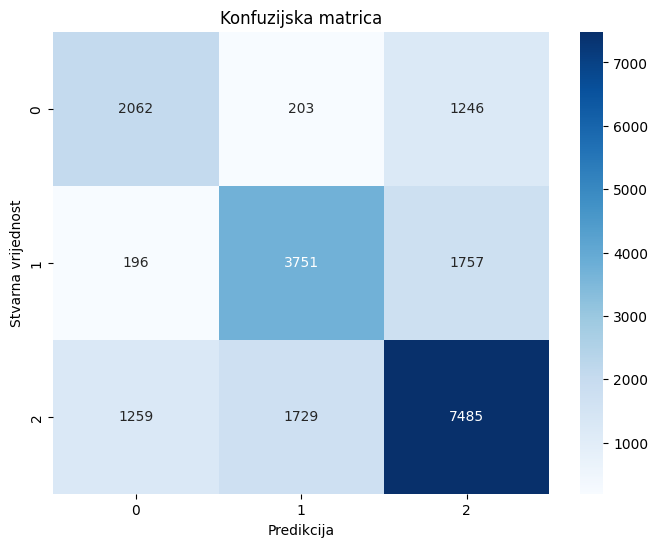

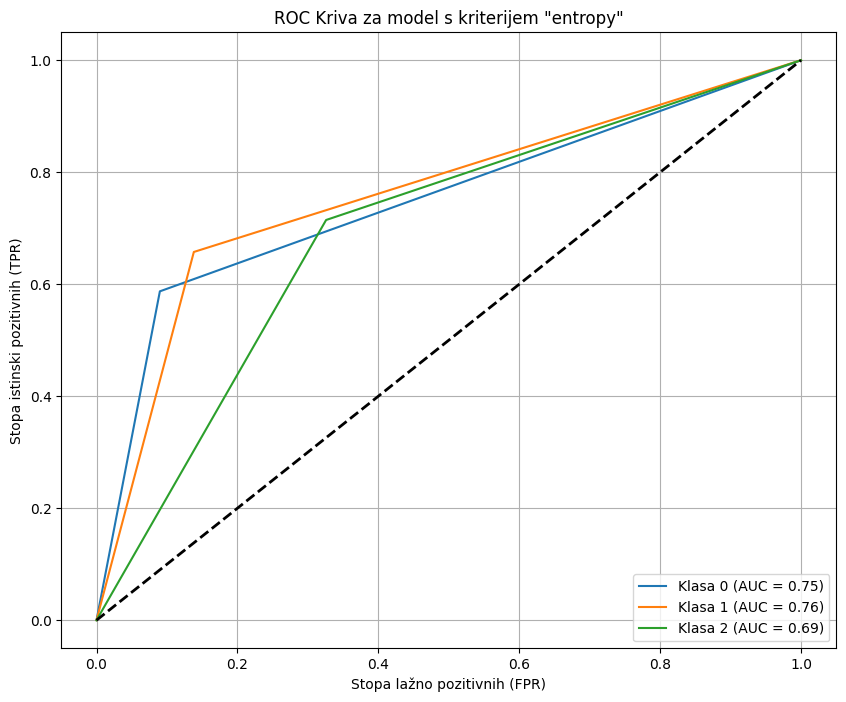

Macro-average AUC: 0.89
Weighted-average AUC: 0.89


In [ ]:
dt_model_entropy = DecisionTreeClassifier(criterion='entropy', random_state=42)
dt_model_entropy.fit(X_train, y_train)
y_pred_entropy = dt_model_entropy.predict(X_test)

print("Rezultati modela")
print("Konfuzijska matrica:\n", confusion_matrix(y_test, y_pred_entropy))
print("\nIzvještaj klasifikacije:\n", classification_report(y_test, y_pred_entropy))
print("Tačnost:", accuracy_score(y_test, y_pred_entropy))

conf_matrix = confusion_matrix(y_test, y_pred_entropy)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=['0', '1', '2'], yticklabels=['0', '1', '2'])
plt.title('Konfuzijska matrica')
plt.xlabel('Predikcija')
plt.ylabel('Stvarna vrijednost')
plt.show()
classes = [0, 1, 2]
y_test_bin = label_binarize(y_test, classes=classes)
y_pred_prob = dt_model_entropy.predict_proba(X_test)


plt.figure(figsize=(10, 8))
for i, class_label in enumerate(classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_prob[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'Klasa {class_label} (AUC = {roc_auc:.2f})')


plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.title('ROC Kriva za model s kriterijem "entropy"')
plt.xlabel('Stopa lažno pozitivnih (FPR)')
plt.ylabel('Stopa istinski pozitivnih (TPR)')
plt.legend(loc='lower right')
plt.grid()
plt.show()

macro_roc_auc = roc_auc_score(y_test_binarized, y_pred_proba, average='macro')
weighted_roc_auc = roc_auc_score(y_test_binarized, y_pred_proba, average='weighted')

print(f"Macro-average AUC: {macro_roc_auc:.2f}")
print(f"Weighted-average AUC: {weighted_roc_auc:.2f}")

Rezultati modela
Konfuzijska matrica:
 [[10095    52   325]
 [   95  9640   738]
 [ 1299  1793  7381]]

Izvještaj klasifikacije:
               precision    recall  f1-score   support

           0       0.88      0.96      0.92     10472
           1       0.84      0.92      0.88     10473
           2       0.87      0.70      0.78     10473

    accuracy                           0.86     31418
   macro avg       0.86      0.86      0.86     31418
weighted avg       0.86      0.86      0.86     31418

Tačnost: 0.8630721242599784


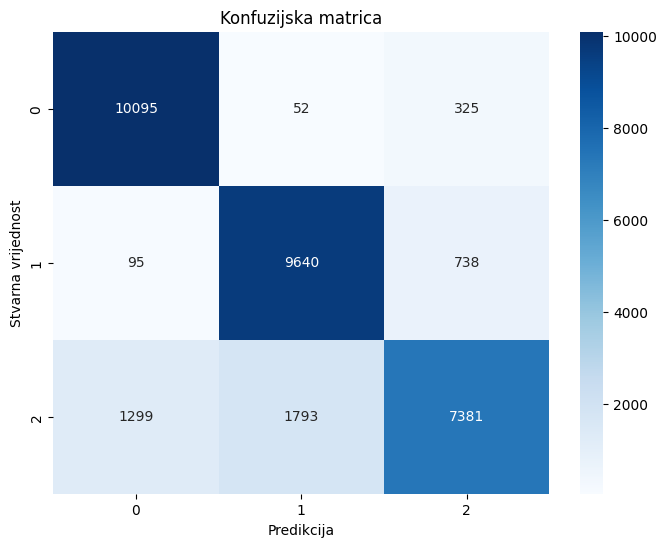

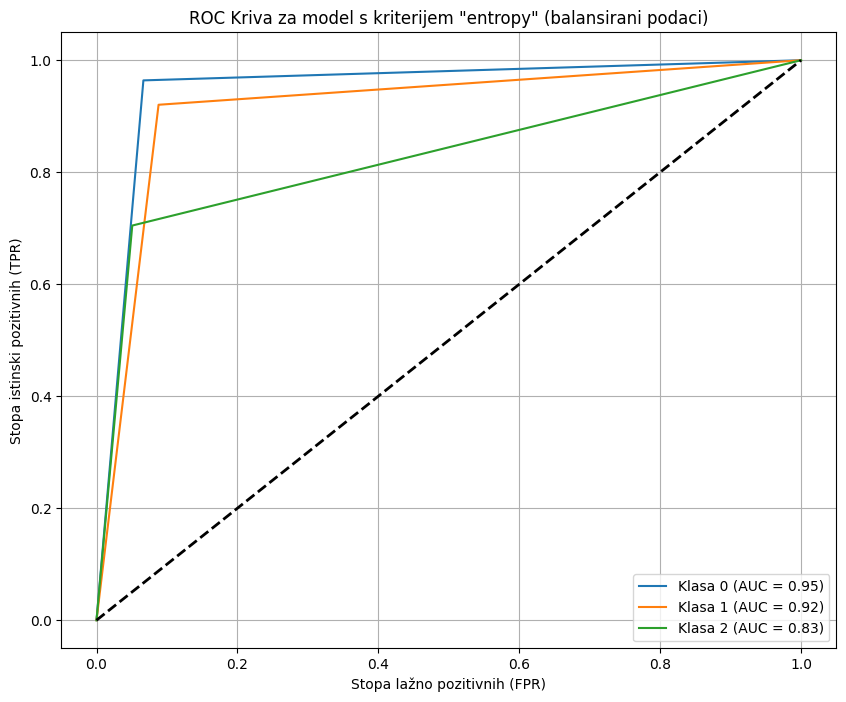

Macro-average AUC: 0.90
Weighted-average AUC: 0.90


In [ ]:
dt_model_entropy = DecisionTreeClassifier(criterion='entropy', random_state=42)
dt_model_entropy.fit(X_train_bal, y_train_bal)
y_pred_entropy = dt_model_entropy.predict(X_test_bal)

print("Rezultati modela")
print("Konfuzijska matrica:\n", confusion_matrix(y_test_bal, y_pred_entropy))
print("\nIzvještaj klasifikacije:\n", classification_report(y_test_bal, y_pred_entropy))
print("Tačnost:", accuracy_score(y_test_bal, y_pred_entropy))


conf_matrix = confusion_matrix(y_test_bal, y_pred_entropy)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=['0', '1', '2'], yticklabels=['0', '1', '2'])
plt.title('Konfuzijska matrica')
plt.xlabel('Predikcija')
plt.ylabel('Stvarna vrijednost')
plt.show()

classes = [0, 1, 2]
y_test_bin_bal = label_binarize(y_test_bal, classes=classes)
y_pred_prob_bal = dt_model_entropy.predict_proba(X_test_bal)


plt.figure(figsize=(10, 8))
for i, class_label in enumerate(classes):
    fpr, tpr, _ = roc_curve(y_test_bin_bal[:, i], y_pred_prob_bal[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'Klasa {class_label} (AUC = {roc_auc:.2f})')


plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.title('ROC Kriva za model s kriterijem "entropy" (balansirani podaci)')
plt.xlabel('Stopa lažno pozitivnih (FPR)')
plt.ylabel('Stopa istinski pozitivnih (TPR)')
plt.legend(loc='lower right')
plt.grid()
plt.show()
macro_roc_auc = roc_auc_score(y_test_bin_bal, y_pred_prob_bal, average='macro')
weighted_roc_auc = roc_auc_score(y_test_bin_bal, y_pred_prob_bal, average='weighted')

print(f"Macro-average AUC: {macro_roc_auc:.2f}")
print(f"Weighted-average AUC: {weighted_roc_auc:.2f}")

In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.tree import DecisionTreeClassifier
import numpy as np

dt_model = DecisionTreeClassifier(criterion='gini', random_state=42)

cv_scores = cross_val_score(dt_model, X_train_bal, y_train_bal, cv=10, scoring='accuracy')

print("Rezultati K-Fold Cross-Validacije:")
print("Svi rezultati za svaki fold:", cv_scores)
print("Prosječna tačnost:", np.mean(cv_scores))
print("Standardna devijacija:", np.std(cv_scores))


Rezultati K-Fold Cross-Validacije:
Svi rezultati za svaki fold: [0.8527212  0.85056099 0.85255033 0.85732474 0.85517626 0.85716559
 0.85374393 0.85851834 0.85247076 0.85135673]
Prosječna tačnost: 0.8541588865982597
Standardna devijacija: 0.0025995402991516683


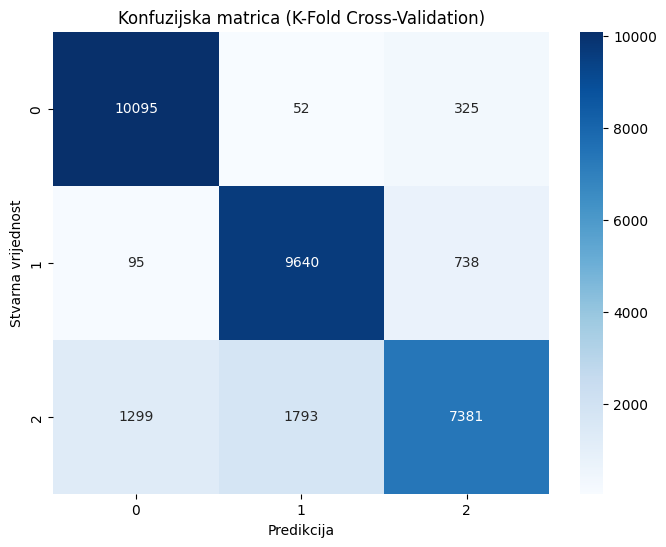

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=['0', '1', '2'], yticklabels=['0', '1', '2'])
plt.title('Konfuzijska matrica (K-Fold Cross-Validation)')
plt.xlabel('Predikcija')
plt.ylabel('Stvarna vrijednost')
plt.show()

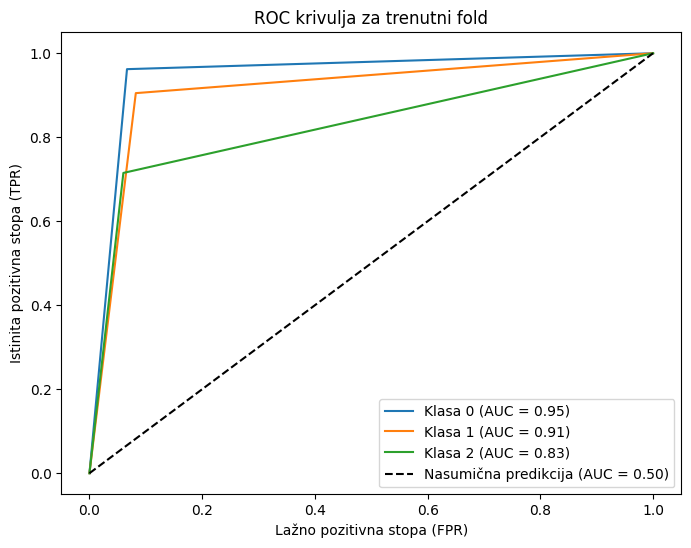

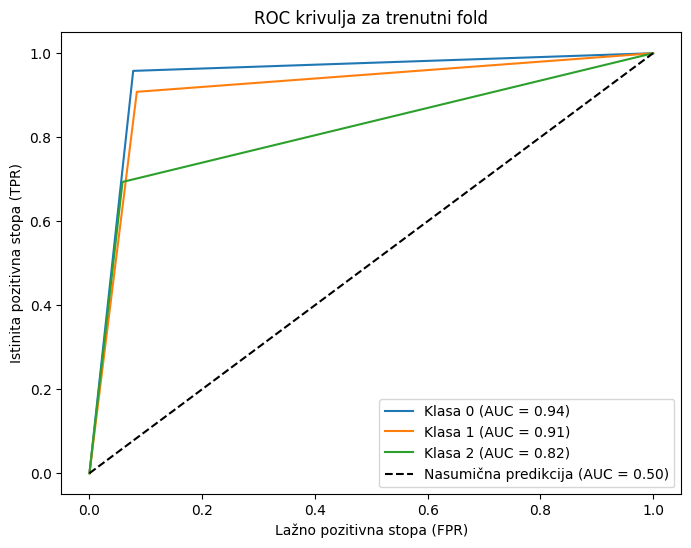

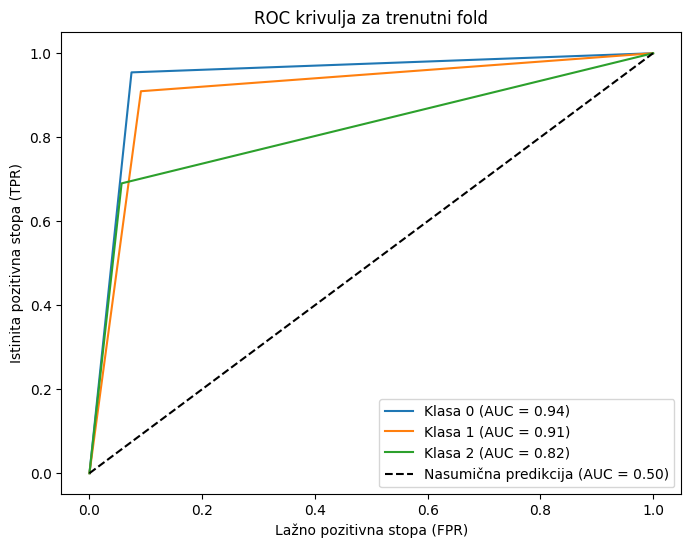

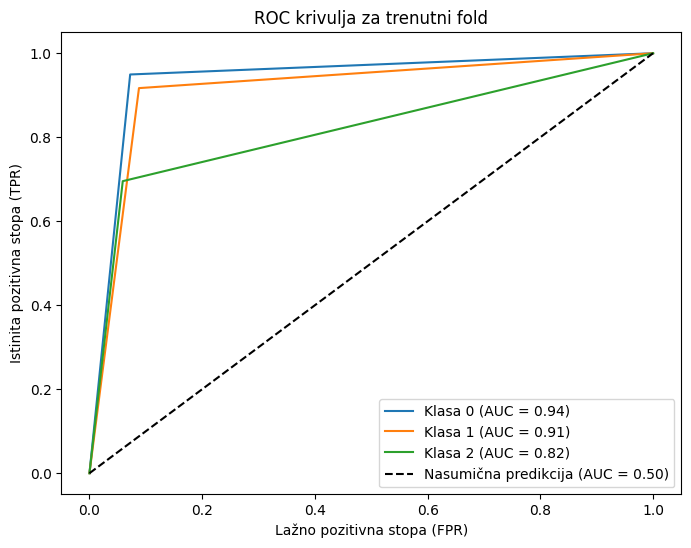

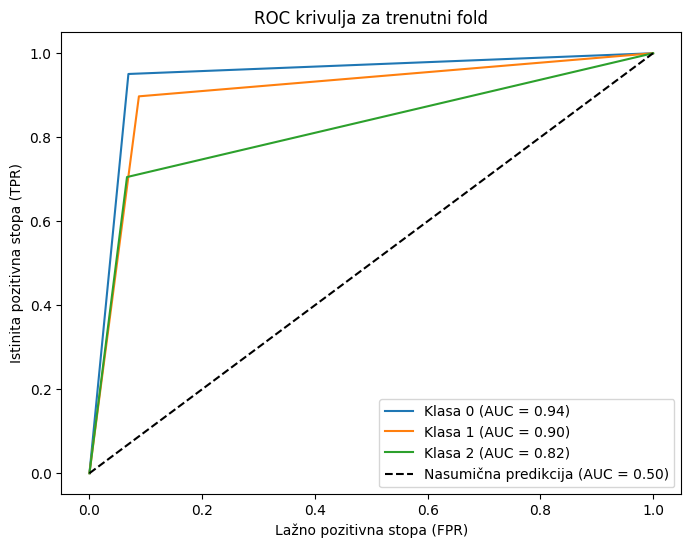

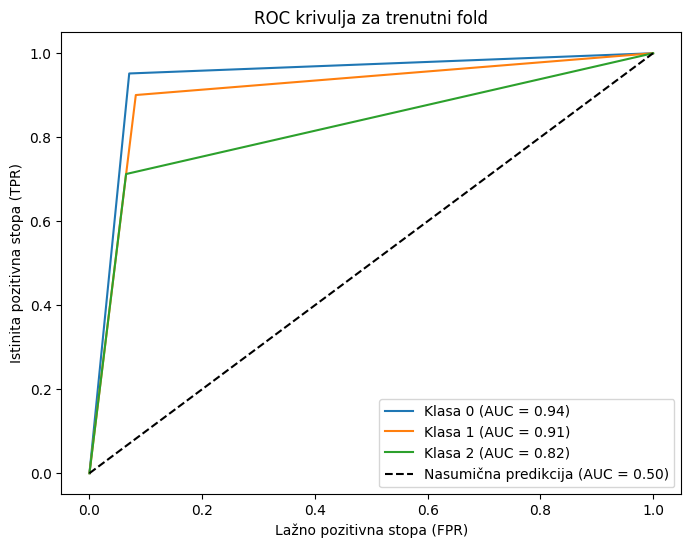

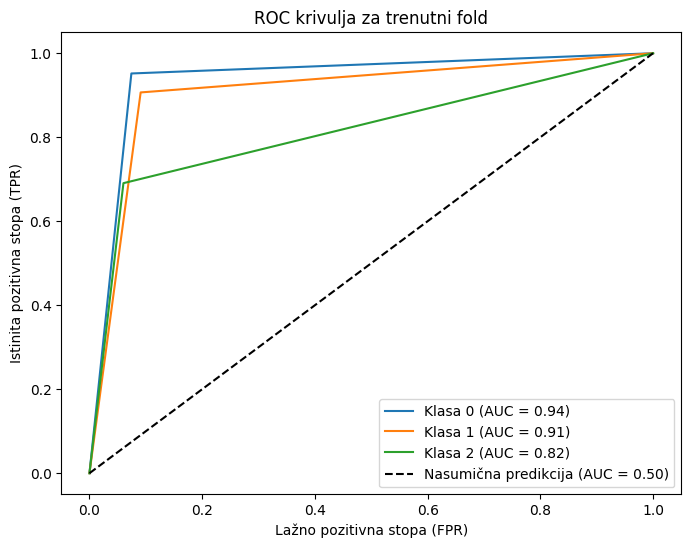

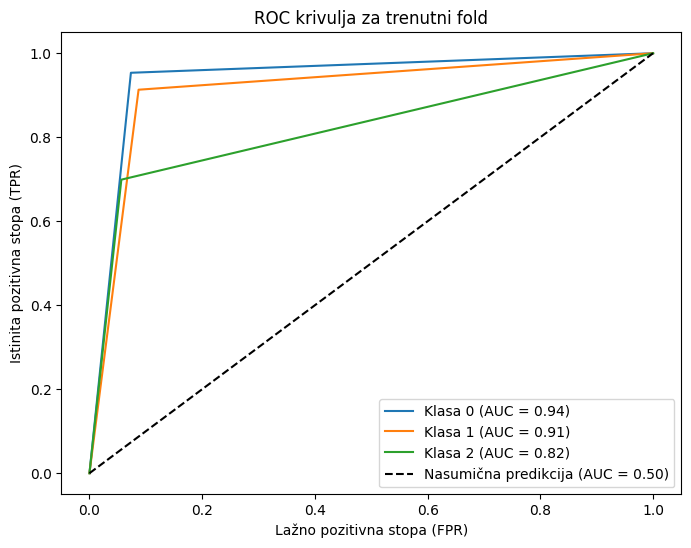

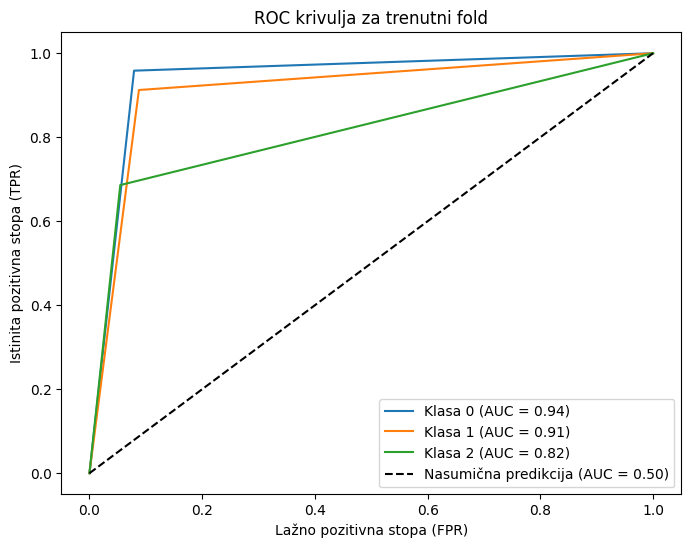

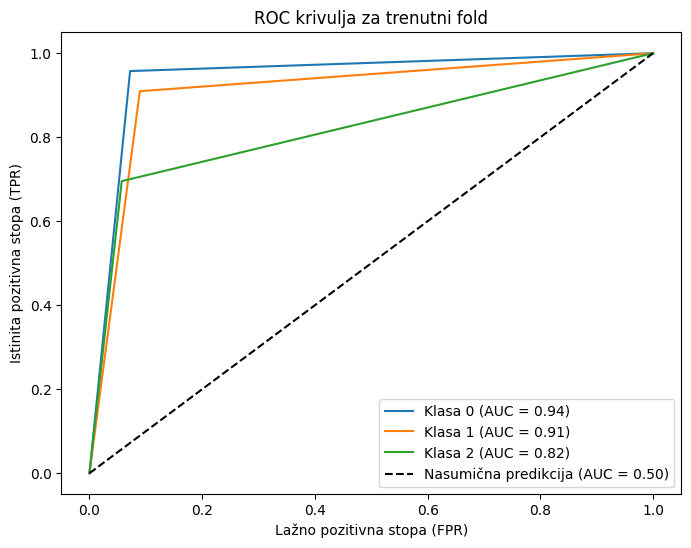


Rezultati K-Fold Cross-Validacije:
Svi rezultati za svaki fold: [0.8606779121578613, 0.8531869181188828, 0.851356727938251, 0.8539030794939126, 0.8510384339937933, 0.8548579613272858, 0.8496856847298481, 0.8551762552717435, 0.8523116097716241, 0.8541417999522559]
Prosječna tačnost: 0.8536336382755458
Standardna devijacija: 0.0028859022320849234
Prosječni AUC za svaki fold: [0.8955044615808663, 0.889890188589162, 0.8885175459536881, 0.8904273096204345, 0.888278825495345, 0.8911434709954644, 0.8872642635473861, 0.8913821914538076, 0.8892337073287181, 0.8906063499641919]
Prosječni AUC za sve foldove: 0.8902248314529064


In [ ]:
from sklearn.model_selection import StratifiedKFold
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import roc_curve, auc, classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import label_binarize
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


dt_model = DecisionTreeClassifier(criterion='gini', random_state=42)


skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)


cv_scores = []
roc_auc_scores = []

classes = [0, 1, 2]

for train_index, test_index in skf.split(X_train_bal, y_train_bal):
    X_train_fold, X_test_fold = X_train_bal.iloc[train_index], X_train_bal.iloc[test_index]
    y_train_fold, y_test_fold = y_train_bal.iloc[train_index], y_train_bal.iloc[test_index]


    dt_model.fit(X_train_fold, y_train_fold)


    y_pred_fold = dt_model.predict(X_test_fold)
    y_pred_proba_fold = dt_model.predict_proba(X_test_fold)


    accuracy = accuracy_score(y_test_fold, y_pred_fold)
    cv_scores.append(accuracy)


    y_test_binarized = label_binarize(y_test_fold, classes=classes)


    fpr = dict()
    tpr = dict()
    roc_auc = dict()
    for i in range(len(classes)):
        fpr[i], tpr[i], _ = roc_curve(y_test_binarized[:, i], y_pred_proba_fold[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])
    roc_auc_scores.append(np.mean(list(roc_auc.values())))


    plt.figure(figsize=(8, 6))
    for i in range(len(classes)):
        plt.plot(fpr[i], tpr[i], label=f"Klasa {i} (AUC = {roc_auc[i]:.2f})")
    plt.plot([0, 1], [0, 1], "k--", label="Nasumična predikcija (AUC = 0.50)")
    plt.title("ROC krivulja za trenutni fold")
    plt.xlabel("Lažno pozitivna stopa (FPR)")
    plt.ylabel("Istinita pozitivna stopa (TPR)")
    plt.legend(loc="lower right")
    plt.show()


print("\nRezultati K-Fold Cross-Validacije:")
print("Svi rezultati za svaki fold:", cv_scores)
print("Prosječna tačnost:", np.mean(cv_scores))
print("Standardna devijacija:", np.std(cv_scores))
print("Prosječni AUC za svaki fold:", roc_auc_scores)
print("Prosječni AUC za sve foldove:", np.mean(roc_auc_scores))
